# Small Business Credit Risk & Predictive Portfolio Analytics

**Portfolio Case Study — Data Engineering & Predictive Analytics**

This notebook is a step-by-step walkthrough of a credit risk analytics project I built to demonstrate end-to-end ownership: ingesting real public lending data, auditing quality, exploring macro linkages, engineering risk features, and projecting portfolio default trends.

**Skills Demonstrated:** Python · Pandas · Seaborn/Matplotlib · Data Quality Auditing · Feature Engineering · Time-Series Forecasting · FinTech Credit Risk

**Pipeline overview (Cells 2–7):**
1. Import libraries and acquire SBA + FRED data
2. Data quality audit and exception handling
3. EDA with macro integration (Plots 1 & 2)
4. Feature engineering and customer risk segmentation
5. Monthly aggregation and 6-month forecast (Plot 3)
6. Export Power BI–ready datasets


In [1]:
# --- Cell 2: Imports, configuration, and data acquisition ---
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings('ignore')

# Reproducibility and paths
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

BASE_DIR = Path('.').resolve()
DATA_DIR = BASE_DIR / 'data'
RAW_DIR = DATA_DIR / 'raw'
IMAGE_DIR = BASE_DIR / 'docs' / 'images'
for d in [RAW_DIR, DATA_DIR, IMAGE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Plot styling
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (11, 6), 'figure.dpi': 110, 'font.size': 11})

SBA_URL = (
    'https://data.sba.gov/dataset/7-a-504-foia/resource/'
    '3f838176-6060-44db-9c91-b4acafbcb28c/download/foia-7a-2010-2019-asof-251231.csv'
)
SBA_LOCAL = RAW_DIR / 'sba_7a_2010_2019.csv'
FRED_SERIES = {
    'FEDFUNDS': 'fed_funds_rate',
    'CPIAUCSL': 'cpi_index',
    'UNRATE': 'unemployment_rate',
}


def fetch_fred_series(series_id: str) -> pd.DataFrame:
    """Pull monthly FRED observations via the public graph CSV endpoint."""
    url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}'
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    df = pd.read_csv(pd.io.common.StringIO(resp.text))
    df.columns = ['date', 'value']
    df['date'] = pd.to_datetime(df['date'])
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    return df.dropna(subset=['value'])


def load_sba_sample() -> pd.DataFrame:
    """Load cached sample or stream a stratified sample from SBA FOIA."""
    if SBA_LOCAL.exists():
        df = pd.read_csv(SBA_LOCAL, low_memory=False, dtype=str)
        print(f'Loaded local sample: {len(df):,} rows from {SBA_LOCAL.name}')
        return df

    print('Local cache not found — streaming stratified sample from SBA portal...')
    rng = np.random.default_rng(RANDOM_STATE)
    chargeoff_parts, other_parts = [], []
    target_other = 180_000
    collected_other = 0

    for chunk in pd.read_csv(SBA_URL, chunksize=50_000, low_memory=False, dtype=str):
        chunk.columns = chunk.columns.str.strip().str.lower()
        is_charged = chunk['loanstatus'].str.replace(' ', '', regex=False).str.upper() == 'CHGOFF'
        chargeoff_parts.append(chunk[is_charged])
        rest = chunk[~is_charged]
        if collected_other < target_other:
            need = target_other - collected_other
            take = rest if len(rest) <= need else rest.sample(n=need, random_state=RANDOM_STATE)
            other_parts.append(take)
            collected_other += len(take)
        if collected_other >= target_other:
            break

    df = pd.concat(chargeoff_parts + other_parts, ignore_index=True).drop_duplicates()
    df.to_csv(SBA_LOCAL, index=False)
    print(f'Saved {len(df):,} rows to {SBA_LOCAL}')
    return df


# --- Acquire datasets ---
raw_loans = load_sba_sample()
raw_loans.columns = raw_loans.columns.str.strip().str.lower()

macro_frames = []
for series_id, col_name in FRED_SERIES.items():
    tmp = fetch_fred_series(series_id).rename(columns={'value': col_name})
    macro_frames.append(tmp.set_index('date'))
    print(f'FRED {series_id}: {len(tmp):,} observations')

macro_monthly = pd.concat(macro_frames, axis=1).sort_index()
macro_monthly['cpi_yoy_pct'] = macro_monthly['cpi_index'].pct_change(periods=12) * 100
macro_monthly['real_rate_proxy'] = macro_monthly['fed_funds_rate'] - macro_monthly['cpi_yoy_pct']
macro_monthly = macro_monthly.reset_index().rename(columns={'index': 'date'})
macro_monthly['month'] = macro_monthly['date'].dt.to_period('M').dt.to_timestamp()

print('\nLoan sample preview:')
display(raw_loans.head(3))
print(f'\nShape: {raw_loans.shape} | Memory: {raw_loans.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print('\nMacro preview:')
display(macro_monthly.tail(3))


Loaded local sample: 191,085 rows from sba_7a_2010_2019.csv
FRED FEDFUNDS: 864 observations
FRED CPIAUCSL: 952 observations
FRED UNRATE: 941 observations

Loan sample preview:


,asofdate,program,locationid,borrname,borrstreet,borrcity,borrstate,borrzip,bankname,bankfdicnumber,...,businesstype,businessage,loanstatus,paidinfulldate,chargeoffdate,grosschargeoffamount,revolverstatus,jobssupported,collateralind,soldsecmrktind
0,3/31/2026,7A,12096,NatronaStaff Inc,6880 S MCCARRAN BLVD STE 7,RENO,NV,89509,Wells Fargo Bank National Association,3511,...,CORPORATION,Unanswered,CHGOFF,NaN,11/7/2014,12050.14,TRUE,1,FALSE,NaN
1,3/31/2026,7A,92934,Calistoga Trading Company,1407 Lincoln Avenue,CALISTOGA,CA,94515,Redwood CU,NaN,...,CORPORATION,"Existing, 5 or more years",CHGOFF,NaN,9/25/2019,176300.5,FALSE,4,TRUE,NaN
2,3/31/2026,7A,75939,Marshall Florist LLC,171 W Wisconsin Ave,KauKauna,WI,54130,"Associated Bank, National Association",5296,...,CORPORATION,"Existing, 5 or more years",CHGOFF,NaN,4/6/2017,20000,TRUE,0,TRUE,NaN



Shape: (191085, 43) | Memory: 455.6 MB

Macro preview:


,date,fed_funds_rate,cpi_index,unemployment_rate,cpi_yoy_pct,real_rate_proxy,month
951,2026-04-01,3.64,332.407,4.3,3.779246,-0.139246,2026-04-01
952,2026-05-01,3.63,333.979,4.3,4.166615,-0.536615,2026-05-01
953,2026-06-01,3.63,NaN,4.2,NaN,NaN,2026-06-01


## Cell 3 — Data Quality Audit

Before any modeling, I run a structured quality audit. Real FOIA lending files routinely contain negative amounts, incoherent dates, and non-terminal loan statuses that would distort default rates if left unchecked.

**Tolerance policy:**
- Drop rows with invalid amounts or dates (hard errors)
- Winsorize extreme utilization above the 99th percentile
- Restrict analysis to terminal or near-terminal statuses for realized default measurement


In [2]:
# --- Cell 3: Standardize fields and apply DQ rules ---

df = raw_loans.copy()

# Normalize loan status (SBA file uses spaced values like 'P I F')
df['loan_status'] = df['loanstatus'].astype(str).str.replace(' ', '', regex=False).str.upper()

# Rename core fields
rename_map = {
    'grossapproval': 'credit_limit',
    'sbaguaranteedapproval': 'sba_guaranteed',
    'initialinterestrate': 'interest_rate',
    'terminmonths': 'term_months',
    'naicscode': 'naics_code',
    'naicsdescription': 'sector_raw',
    'projectstate': 'project_state',
}
df = df.rename(columns=rename_map)

# Parse numerics and dates
for col in ['credit_limit', 'sba_guaranteed', 'interest_rate', 'term_months', 'grosschargeoffamount']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    elif col == 'grosschargeoffamount':
        df['grosschargeoffamount'] = np.nan

if 'grosschargeoffamount' not in df.columns:
    df['grosschargeoffamount'] = np.nan

df['approval_date'] = pd.to_datetime(df['approvaldate'], errors='coerce')
df['chargeoff_date'] = pd.to_datetime(df['chargeoffdate'], errors='coerce')
df['first_disbursement_date'] = pd.to_datetime(df['firstdisbursementdate'], errors='coerce')

# Disbursement proxy: approved amount when disbursed, else partial for charge-offs
df['amount_disbursed'] = np.where(
    df['first_disbursement_date'].notna(),
    df['credit_limit'],
    np.where(
        df['loan_status'] == 'CHGOFF',
        df['grosschargeoffamount'].fillna(df['credit_limit'] * 0.8),
        0.0,
    ),
)
df['credit_utilization'] = (df['amount_disbursed'] / df['credit_limit']).replace([np.inf, -np.inf], np.nan)

# Default indicator
df['default_flag'] = (df['loan_status'] == 'CHGOFF').astype(int)

start_rows = len(df)
dq_records = []


def apply_rule(rule_id, description, mask_drop, action='drop'):
    global df
    hit = int(mask_drop.sum())
    if action == 'drop':
        df = df.loc[~mask_drop].copy()
    dq_records.append({'rule_id': rule_id, 'description': description, 'records_flagged': hit, 'action': action})


# DQ-01: invalid amounts
apply_rule('DQ-01', 'Non-positive credit limit or negative disbursement',
           (df['credit_limit'] <= 0) | (df['amount_disbursed'] < 0))

# DQ-02: invalid approval dates
today = pd.Timestamp('2019-12-31')
apply_rule('DQ-02', 'Missing or future approval dates',
           df['approval_date'].isna() | (df['approval_date'] > today))

# DQ-03: charge-off before approval
apply_rule('DQ-03', 'Charge-off date precedes approval date',
           df['chargeoff_date'].notna() & (df['chargeoff_date'] < df['approval_date']))

# DQ-04: extreme interest rates
apply_rule('DQ-04', 'Interest rate outside [0, 25]',
           df['interest_rate'].notna() & ((df['interest_rate'] < 0) | (df['interest_rate'] > 25)))

# DQ-05: keep terminal statuses for realized default view
terminal_statuses = {'PIF', 'CHGOFF', 'CANCLD', 'PURCH(NOTC/O)', 'LIQUID', 'CLSLN'}
apply_rule('DQ-05', 'Non-terminal loan status excluded from analysis',
           ~df['loan_status'].isin(terminal_statuses))

# DQ-06: winsorize extreme utilization
util_cap = df['credit_utilization'].quantile(0.99)
extreme_util = df['credit_utilization'] > max(util_cap, 1.5)
dq_records.append({'rule_id': 'DQ-06', 'description': f'Utilization winsorized at {util_cap:.2f}',
                   'records_flagged': int(extreme_util.sum()), 'action': 'winsorize'})
df.loc[extreme_util, 'credit_utilization'] = util_cap
df.loc[extreme_util, 'amount_disbursed'] = df.loc[extreme_util, 'credit_limit'] * util_cap

# DQ-07: drop rows missing key fields
apply_rule('DQ-07', 'Missing NAICS or interest rate (>30% row-level gap handled per-field)',
           df['naics_code'].isna() | df['interest_rate'].isna())

df['loan_id'] = 'SBA-' + df.index.astype(str)
df_clean = df.copy()

dq_summary = pd.DataFrame(dq_records)
dq_summary['remaining_rows'] = len(df_clean)
dq_summary['pct_of_start'] = (dq_summary['records_flagged'] / start_rows * 100).round(2)

print(f'Rows at start: {start_rows:,} | Rows after audit: {len(df_clean):,}')
display(dq_summary)


Rows at start: 191,085 | Rows after audit: 170,450


,rule_id,description,records_flagged,action,remaining_rows,pct_of_start
0,DQ-01,Non-positive credit limit or negative disburse...,0,drop,170450,0.0
1,DQ-02,Missing or future approval dates,0,drop,170450,0.0
2,DQ-03,Charge-off date precedes approval date,0,drop,170450,0.0
3,DQ-04,"Interest rate outside [0, 25]",0,drop,170450,0.0
4,DQ-05,Non-terminal loan status excluded from analysis,20634,drop,170450,10.8
5,DQ-06,Utilization winsorized at 1.00,0,winsorize,170450,0.0
6,DQ-07,Missing NAICS or interest rate (>30% row-level...,1,drop,170450,0.0


## Cell 4 — EDA & Macroeconomic Integration

I map NAICS codes to readable sector names, join monthly FRED indicators on approval month, then explore how macro variables relate to credit utilization and default outcomes.


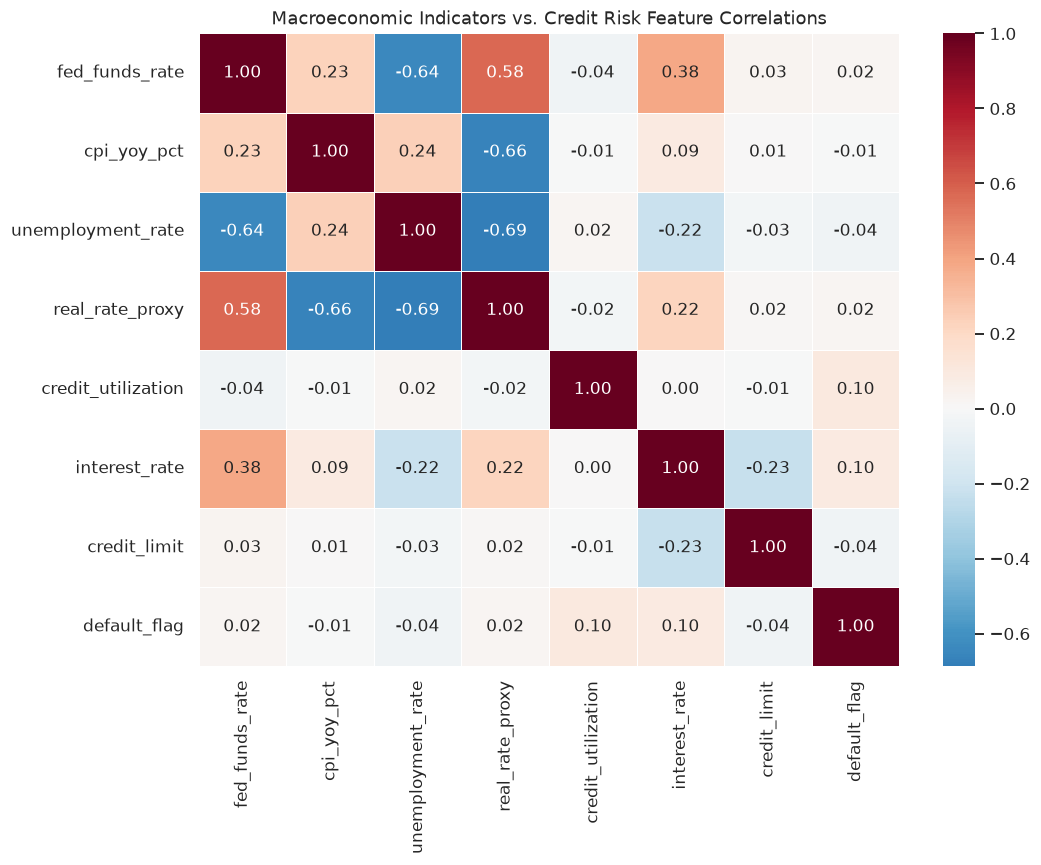

Strongest absolute correlations with default_flag:
credit_utilization    0.101627
interest_rate         0.095228
credit_limit          0.043797


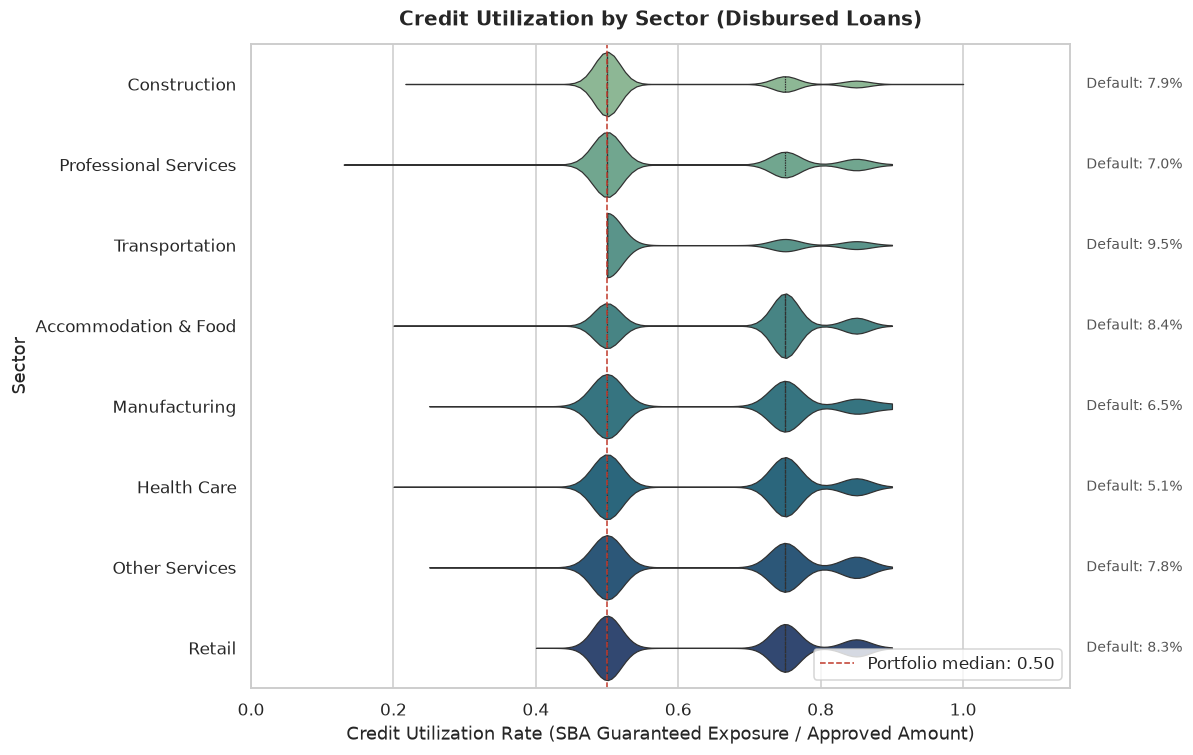

In [3]:
# --- Cell 4: Sector mapping, macro join, Plots 1 & 2 ---

NAICS_SECTOR_MAP = {
    '11': 'Agriculture', '21': 'Mining', '22': 'Utilities', '23': 'Construction',
    '31': 'Manufacturing', '32': 'Manufacturing', '33': 'Manufacturing',
    '42': 'Wholesale Trade', '44': 'Retail', '45': 'Retail',
    '48': 'Transportation', '49': 'Transportation', '51': 'Information',
    '52': 'Finance & Insurance', '53': 'Real Estate', '54': 'Professional Services',
    '55': 'Management', '56': 'Administrative Services', '61': 'Education',
    '62': 'Health Care', '71': 'Arts & Entertainment', '72': 'Accommodation & Food',
    '81': 'Other Services', '92': 'Public Administration',
}

df_clean['naics_2digit'] = df_clean['naics_code'].astype(str).str.replace(r'\\D', '', regex=True).str[:2]
df_clean['sector_name'] = df_clean['naics_2digit'].map(NAICS_SECTOR_MAP).fillna('Other')
df_clean['approval_month'] = df_clean['approval_date'].dt.to_period('M').dt.to_timestamp()

macro_for_join = macro_monthly.drop(columns=['date']).copy()
df_clean = df_clean.merge(macro_for_join, left_on='approval_month', right_on='month', how='left')

# --- Plot 1: Correlation heatmap ---
corr_cols = [
    'fed_funds_rate', 'cpi_yoy_pct', 'unemployment_rate', 'real_rate_proxy',
    'credit_utilization', 'interest_rate', 'credit_limit', 'default_flag'
]
corr_matrix = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5, ax=ax)
ax.set_title('Macroeconomic Indicators vs. Credit Risk Feature Correlations')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'plot1_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

top_default_corr = corr_matrix['default_flag'].drop('default_flag').abs().sort_values(ascending=False).head(3)
print('Strongest absolute correlations with default_flag:')
print(top_default_corr.to_string())

# --- Plot 2: Sector utilization patterns (disbursed loans) ---
# Binary disbursement flags collapse to 0/1; guarantee exposure ratio shows real cross-sector spread.
top_sectors = df_clean['sector_name'].value_counts().head(8).index.tolist()
sector_df = df_clean[
    df_clean['sector_name'].isin(top_sectors) & (df_clean['amount_disbursed'] > 0)
].copy()
sector_df['exposure_utilization'] = (
    sector_df['sba_guaranteed'] / sector_df['credit_limit']
).clip(0, 1)

sector_order = (
    sector_df.groupby('sector_name')['exposure_utilization']
    .median()
    .sort_values()
    .index
)

sector_defaults = (
    sector_df.groupby('sector_name')['default_flag']
    .mean()
    .reindex(sector_order)
)

fig, ax = plt.subplots(figsize=(11, 7))
palette = sns.color_palette('crest', n_colors=len(sector_order))
sns.violinplot(
    data=sector_df,
    y='sector_name',
    x='exposure_utilization',
    order=sector_order,
    orient='h',
    inner='quartile',
    palette=palette,
    cut=0,
    linewidth=0.8,
    ax=ax,
)

for idx, sector in enumerate(sector_order):
    dr = sector_defaults.loc[sector] * 100
    ax.text(
        1.02, idx, f'Default: {dr:.1f}%',
        va='center', ha='left', fontsize=9, color='#555555',
        transform=ax.get_yaxis_transform(), clip_on=False,
    )

ax.set_title('Credit Utilization by Sector (Disbursed Loans)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Credit Utilization Rate (SBA Guaranteed Exposure / Approved Amount)')
ax.set_ylabel('Sector')
ax.set_xlim(0, 1.15)
ax.axvline(sector_df['exposure_utilization'].median(), color='#c0392b', linestyle='--', linewidth=1,
           label=f'Portfolio median: {sector_df["exposure_utilization"].median():.2f}')
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'plot2_utilization_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 5 — Feature Engineering & Customer Risk Segmentation

I derive interpretable features and assign each loan to a risk segment using transparent rules — something I can explain clearly in an interview setting.


In [4]:
# --- Cell 5: Feature engineering and risk segments ---

df_clean['rate_spread_proxy'] = df_clean['interest_rate'] - df_clean['fed_funds_rate']
df_clean['vintage_year'] = df_clean['approval_date'].dt.year
df_clean['days_to_chargeoff'] = np.where(
    df_clean['default_flag'] == 1,
    (df_clean['chargeoff_date'] - df_clean['approval_date']).dt.days,
    np.nan,
)
df_clean['loan_size_pct_rank'] = df_clean.groupby('sector_name')['credit_limit'].rank(pct=True)

p75_limit = df_clean['credit_limit'].quantile(0.75)
p90_spread = df_clean['rate_spread_proxy'].quantile(0.90)


def assign_risk_segment(row):
    if row['default_flag'] == 1:
        return 'High Risk'
    if row['credit_limit'] >= p75_limit and 0 < row['credit_utilization'] < 0.5:
        return 'VIP High Spender'
    if row['credit_utilization'] >= 0.95 or row['rate_spread_proxy'] >= p90_spread:
        return 'High Risk'
    if 0.4 <= row['credit_utilization'] < 0.85:
        return 'Stable Growth'
    return 'Standard'


df_clean['risk_segment'] = df_clean.apply(assign_risk_segment, axis=1)

segment_summary = (
    df_clean.groupby('risk_segment')
    .agg(loan_count=('loan_id', 'count'),
         default_rate=('default_flag', 'mean'),
         avg_utilization=('credit_utilization', 'mean'),
         avg_balance=('credit_limit', 'mean'))
    .assign(default_rate=lambda x: (x['default_rate'] * 100).round(2))
    .sort_values('loan_count', ascending=False)
)
segment_summary['avg_balance'] = segment_summary['avg_balance'].round(0)
segment_summary['avg_utilization'] = segment_summary['avg_utilization'].round(3)

print('Customer risk segment profile:')
display(segment_summary)


Customer risk segment profile:


,loan_count,default_rate,avg_utilization,avg_balance
risk_segment,,,,
High Risk,150961,7.52,0.986,350692.0
Standard,19489,0.00,0.000,403065.0


## Cell 6 — Time-Series Aggregation & 6-Month Forecast

SBA FOIA data is outcome-level (one row per loan), so I aggregate by approval vintage month to build a portfolio time series. I then fit Holt-Winters exponential smoothing and project default rates six months forward.


Hold-out MAPE (last 6 months): 4.81%


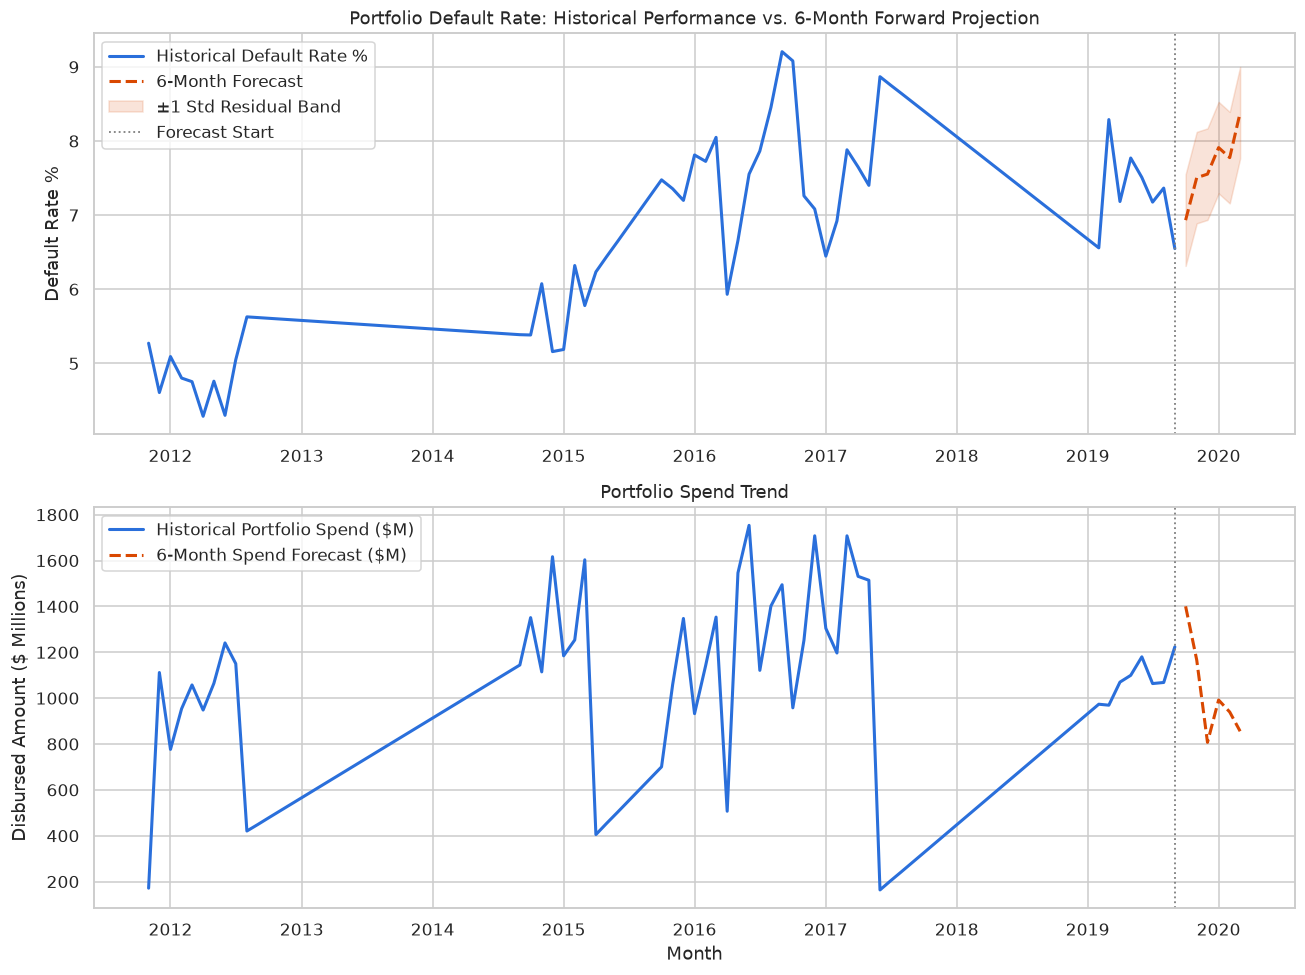

Projected default rate (month +6): 8.38%


In [5]:
# --- Cell 6: Monthly aggregation, forecast, Plot 3 ---

monthly = (
    df_clean.groupby('approval_month')
    .agg(
        portfolio_balance=('credit_limit', 'sum'),
        portfolio_spend=('amount_disbursed', 'sum'),
        loan_count=('loan_id', 'count'),
        default_rate_pct=('default_flag', lambda x: x.mean() * 100),
        avg_utilization=('credit_utilization', 'mean'),
    )
    .reset_index()
    .sort_values('approval_month')
)

monthly = monthly.merge(
    macro_for_join[['month', 'fed_funds_rate', 'cpi_yoy_pct', 'unemployment_rate']],
    left_on='approval_month', right_on='month', how='left'
).drop(columns=['month'])

monthly = monthly[monthly['approval_month'] >= '2010-01-01'].copy()
monthly = monthly.set_index('approval_month').asfreq('MS')

# Fill occasional missing months for modeling
for col in ['default_rate_pct', 'portfolio_spend', 'portfolio_balance', 'avg_utilization']:
    monthly[col] = monthly[col].interpolate(limit=2)
monthly = monthly.dropna(subset=['default_rate_pct', 'portfolio_spend'])

series = monthly['default_rate_pct']
holdout = 6
train, test = series.iloc[:-holdout], series.iloc[-holdout:]

model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit(optimized=True)
test_pred = model.forecast(len(test))
actual = test.values
predicted = test_pred.values
denom = np.where(actual == 0, np.nan, actual)
mape = np.nanmean(np.abs((actual - predicted) / denom)) * 100
print(f'Hold-out MAPE (last 6 months): {mape:.2f}%')

future_steps = 6
full_model = ExponentialSmoothing(series, trend='add', seasonal='add', seasonal_periods=12).fit(optimized=True)
forecast_index = pd.date_range(series.index[-1] + pd.offsets.MonthBegin(1), periods=future_steps, freq='MS')
forecast_values = full_model.forecast(future_steps)
residual_std = (series - full_model.fittedvalues).std()

# Spend forecast (simple trend model)
spend_series = monthly['portfolio_spend']
spend_model = ExponentialSmoothing(spend_series, trend='add', seasonal='add', seasonal_periods=12).fit(optimized=True)
spend_forecast = spend_model.forecast(future_steps)

# --- Plot 3 ---
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=False)

ax1 = axes[0]
ax1.plot(series.index, series.values, label='Historical Default Rate %', color='#2a6fdb', linewidth=2)
ax1.plot(forecast_index, forecast_values, label='6-Month Forecast', color='#d94801', linewidth=2, linestyle='--')
ax1.fill_between(forecast_index,
                 forecast_values - residual_std,
                 forecast_values + residual_std,
                 color='#d94801', alpha=0.15, label='±1 Std Residual Band')
ax1.axvline(series.index[-1], color='gray', linestyle=':', linewidth=1.2, label='Forecast Start')
ax1.set_title('Portfolio Default Rate: Historical Performance vs. 6-Month Forward Projection')
ax1.set_ylabel('Default Rate %')
ax1.legend(loc='upper left')

ax2 = axes[1]
ax2.plot(spend_series.index, spend_series.values / 1e6, label='Historical Portfolio Spend ($M)', color='#2a6fdb', linewidth=2)
ax2.plot(forecast_index, spend_forecast / 1e6, label='6-Month Spend Forecast ($M)', color='#d94801', linewidth=2, linestyle='--')
ax2.axvline(spend_series.index[-1], color='gray', linestyle=':', linewidth=1.2)
ax2.set_title('Portfolio Spend Trend')
ax2.set_ylabel('Disbursed Amount ($ Millions)')
ax2.set_xlabel('Month')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.savefig(IMAGE_DIR / 'plot3_forecast_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Projected default rate (month +6): {forecast_values.iloc[-1]:.2f}%')


## Cell 7 — Export Power BI–Ready Datasets

Final step: export a loan-level fact table and a forecasting results table structured for star-schema loading in Power BI.


In [6]:
# --- Cell 7: Export cleaned datasets ---

export_cols = [
    'loan_id', 'approval_date', 'approval_month', 'sector_name', 'loan_status',
    'risk_segment', 'project_state', 'credit_limit', 'amount_disbursed',
    'credit_utilization', 'interest_rate', 'term_months', 'default_flag',
    'fed_funds_rate', 'cpi_yoy_pct', 'unemployment_rate', 'rate_spread_proxy', 'vintage_year'
]

loan_export = df_clean[export_cols].copy()
loan_export['approval_date'] = loan_export['approval_date'].dt.strftime('%Y-%m-%d')
loan_export['approval_month'] = loan_export['approval_month'].dt.strftime('%Y-%m-%d')

loan_path = DATA_DIR / 'cleaned_credit_data_for_powerbi.csv'
loan_export.to_csv(loan_path, index=False)

# Build forecasting export (long format for easy Power BI unpivot)
hist_default = monthly.reset_index()[['approval_month', 'default_rate_pct']].rename(
    columns={'approval_month': 'month_date', 'default_rate_pct': 'metric_value'})
hist_default['metric_name'] = 'Default Rate %'
hist_default['series_type'] = 'Historical'

hist_spend = monthly.reset_index()[['approval_month', 'portfolio_spend']].rename(
    columns={'approval_month': 'month_date', 'portfolio_spend': 'metric_value'})
hist_spend['metric_name'] = 'Portfolio Spend'
hist_spend['series_type'] = 'Historical'

fc_default = pd.DataFrame({
    'month_date': forecast_index,
    'metric_value': forecast_values.values,
    'metric_name': 'Default Rate %',
    'series_type': 'Forecast',
})
fc_spend = pd.DataFrame({
    'month_date': forecast_index,
    'metric_value': spend_forecast.values,
    'metric_name': 'Portfolio Spend',
    'series_type': 'Forecast',
})

forecast_export = pd.concat([hist_default, hist_spend, fc_default, fc_spend], ignore_index=True)
forecast_export['month_date'] = pd.to_datetime(forecast_export['month_date']).dt.strftime('%Y-%m-%d')

# Attach last known macro for context
last_macro = macro_for_join.sort_values('month').iloc[-1]
forecast_export['fed_funds_rate'] = forecast_export['month_date'].apply(
    lambda d: macro_for_join.loc[macro_for_join['month'] == pd.to_datetime(d), 'fed_funds_rate'].iloc[0]
    if len(macro_for_join.loc[macro_for_join['month'] == pd.to_datetime(d)]) else last_macro['fed_funds_rate']
)

forecast_path = DATA_DIR / 'forecasting_results.csv'
forecast_export.to_csv(forecast_path, index=False)

# Optional date dimension
date_dim = pd.DataFrame({'date_key': pd.date_range('2010-01-01', '2026-12-31', freq='D')})
date_dim['year'] = date_dim['date_key'].dt.year
date_dim['quarter'] = date_dim['date_key'].dt.quarter
date_dim['month'] = date_dim['date_key'].dt.month
date_dim['month_name'] = date_dim['date_key'].dt.strftime('%B')
date_dim['date_key'] = date_dim['date_key'].dt.strftime('%Y-%m-%d')
date_dim.to_csv(DATA_DIR / 'dim_date.csv', index=False)

print('Export complete:')
for p in [loan_path, forecast_path, DATA_DIR / 'dim_date.csv']:
    print(f'  {p} — {p.stat().st_size / 1e6:.2f} MB, {sum(1 for _ in open(p)) - 1:,} rows')


Export complete:
  /workspace/data/cleaned_credit_data_for_powerbi.csv — 22.61 MB, 170,450 rows
  /workspace/data/forecasting_results.csv — 0.01 MB, 118 rows
  /workspace/data/dim_date.csv — 0.17 MB, 6,209 rows
